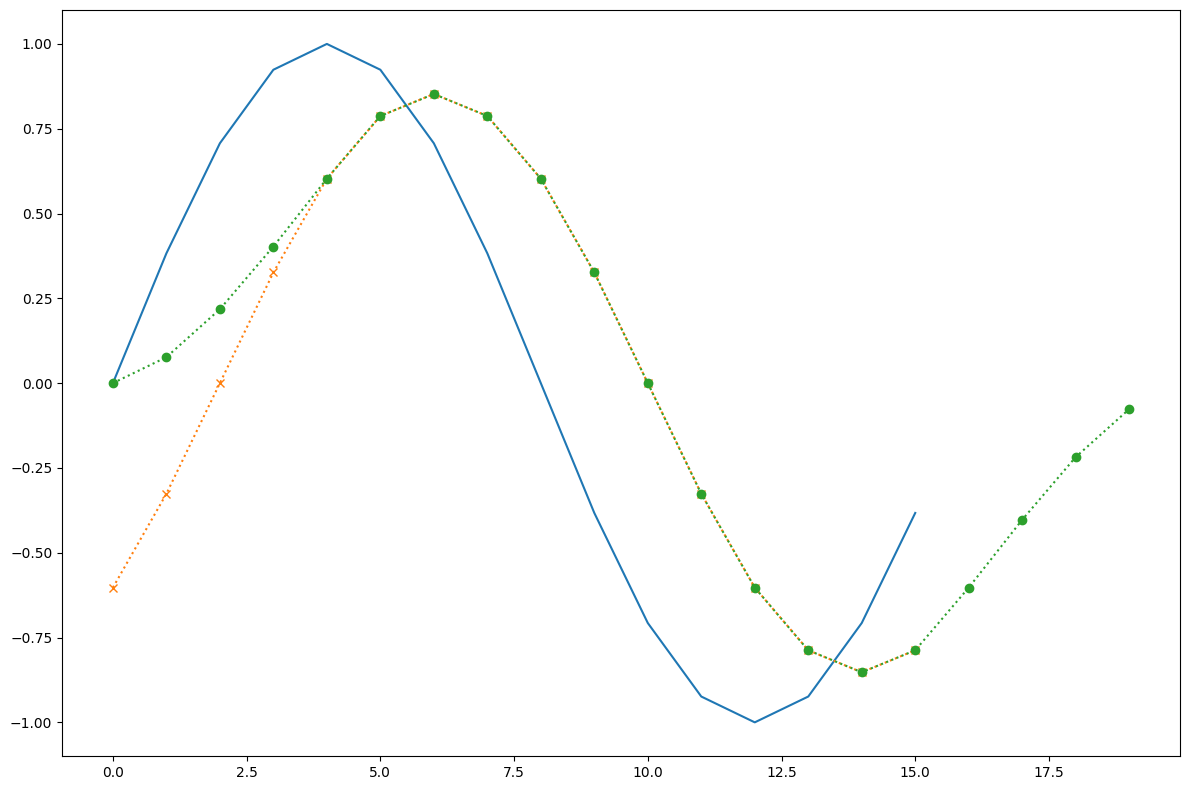

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Aug 27 18:42:42 2026

@author: mariano
"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# Parámetros
N = 16
k = 1   # frecuencia: 2 ciclos en N muestras

# 1. Señal senoidal
n = np.arange(N)
x = np.sin(2 * np.pi * n * k / N)

# 2. Respuesta al impulso: promedio de 5 muestras (filtro FIR)
h = np.zeros(N)
h[:5] = 1/5   # h[n] = 0.2 para n=0..4, luego ceros

h5 = np.zeros(5)
h5[:5] = 1/5

# -----------------------------------------------------------
# Convolución circular mediante FFT (producto en frecuencia)
# -----------------------------------------------------------
X = np.fft.fft(x)
H = np.fft.fft(h)
y_fft = np.fft.ifft(X * H).real   # parte real (debería ser real)

# -----------------------------------------------------------
# Convolución lineal
# -----------------------------------------------------------

y_h5 = sig.convolve(x, h5, mode = 'full')

# -----------------------------------------------------------
# Gráficas
# -----------------------------------------------------------
plt.figure(figsize=(12, 8))

plt.plot(x)
plt.plot(y_fft, ':x')
plt.plot(y_h5, ':o')

plt.tight_layout()
plt.show()


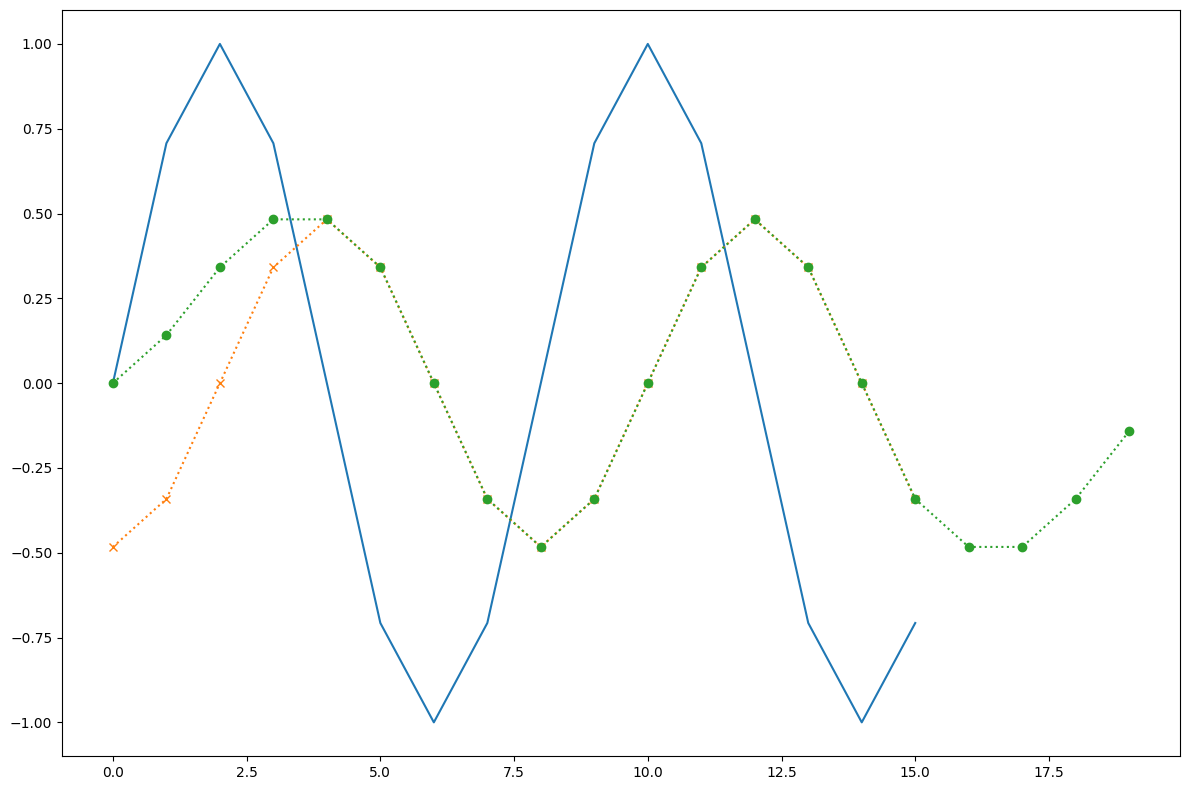

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Aug 27 18:42:42 2026

@author: mariano
"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# Parámetros
N = 16
k = 2   # frecuencia: 2 ciclos en N muestras

# 1. Señal senoidal
n = np.arange(N)
x = np.sin(2 * np.pi * n * k / N)

# 2. Respuesta al impulso: promedio de 5 muestras (filtro FIR)
h = np.zeros(N)
h[:5] = 1/5   # h[n] = 0.2 para n=0..4, luego ceros

h5 = np.zeros(5)
h5[:5] = 1/5

# -----------------------------------------------------------
# Convolución circular mediante FFT (producto en frecuencia)
# -----------------------------------------------------------
X = np.fft.fft(x)
H = np.fft.fft(h)
y_fft = np.fft.ifft(X * H).real   # parte real (debería ser real)

# -----------------------------------------------------------
# Convolución lineal
# -----------------------------------------------------------

y_h5 = sig.convolve(x, h5, mode = 'full')

# -----------------------------------------------------------
# Gráficas
# -----------------------------------------------------------
plt.figure(figsize=(12, 8))

plt.plot(x)
plt.plot(y_fft, ':x')
plt.plot(y_h5, ':o')

plt.tight_layout()
plt.show()


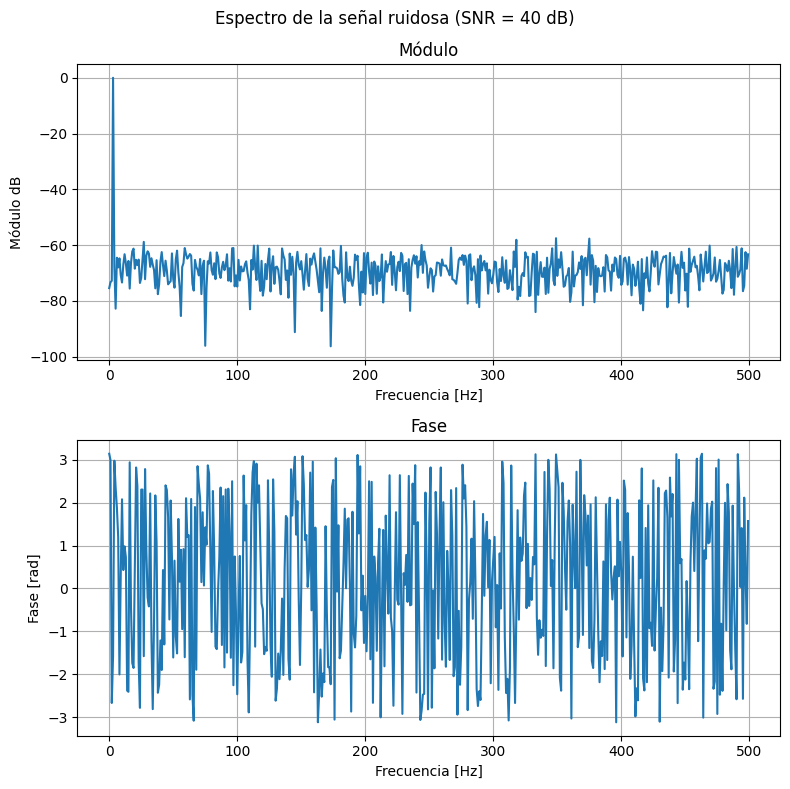

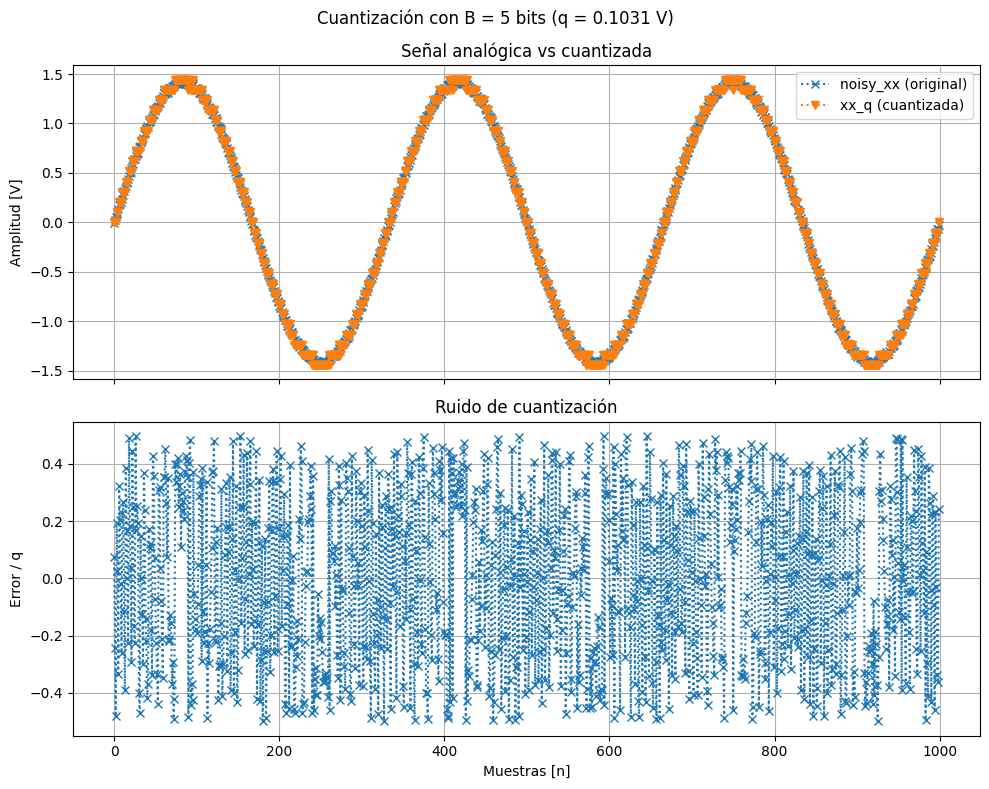

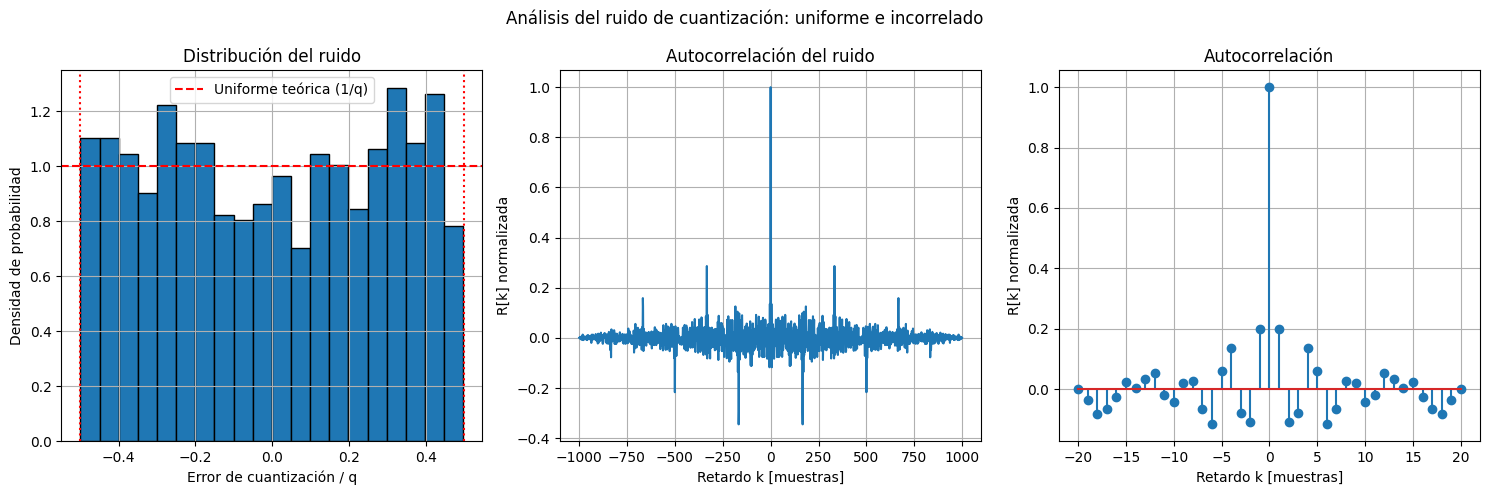

Varianza medida  : 0.0009295592742764074
Varianza teórica : 0.0008862304687499999


In [18]:
#%% ------------------ IMPORTACION DE MODULOS -------------------

import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy

#%% ---------------------- DEFINICION CTES ----------------------

fs = 1000 #Frecuencia muestreo (Hz) 
N = 1000 #Cant. muestras
vmax = np.sqrt(2) #amp max
dc = 0 #offset
ff = 3 #Frecuencia sinusoidal (Hz)
ph = 0 #rad
SNR = 40 #dB
Psen = 1 #Potencia media senoide [Watt]
ur = 0 #Media del ruido

k=4
delta_f=1

# ADC

B = 5 # bits
Vfs  = 1.65 # Volts

qq = 2*Vfs / (2**B)   # paso de cuantización [V]


#%% ------------------------- FUNCIONES -------------------------

# Generador de señal senoidal
def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Generador de ruido
def gen_noise (SNR = SNR, Psen = Psen, ur = ur, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Psen / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido


#%% ------------------------ MAIN SCRIPT ------------------------

#Invoco la función generadora de senoides
tt, xx = gen_sin( vmax, dc, ff, ph, N, fs) 

#Invoco la función generadora de ruido
ruido = gen_noise (SNR, Psen, ur, N)

#Armo manualmente la señal ruidosa
noisy_xx = xx + ruido

#Armo vector de frecuencia
frec= np.arange(N//2) * fs/N

#Calculo fft de la señal ruidosa
nXX = 1/N * np.fft.fft(noisy_xx)

plt.close('all')

# Espectro del módulo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
fig.suptitle("Espectro de la señal ruidosa (SNR = {:d} dB)".format(SNR))

ax1.plot(frec, 10 * np.log10( 2*(np.abs(nXX[:N//2]) )**2 ) )
ax1.set_title("Módulo")
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Módulo dB")
ax1.grid(True)

# Segundo subplot: fase
ax2.plot(frec, np.angle(nXX[:N//2]))
ax2.set_title("Fase")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Fase [rad]")
ax2.grid(True)

# Ajustar layout para que no se superpongan
plt.tight_layout()
plt.show()

#%% Cuantizamos

xx_q = np.round(noisy_xx / qq) * qq

nq =  xx_q - noisy_xx


fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Cuantización con B = {:d} bits (q = {:.4f} V)".format(B, qq))

# Señal original vs cuantizada
ax3.plot(noisy_xx, ':x', label='noisy_xx (original)')
ax3.plot(xx_q, ':v', label='xx_q (cuantizada)')
ax3.set_ylabel("Amplitud [V]")
ax3.set_title("Señal analógica vs cuantizada")
ax3.legend()
ax3.grid(True)

# Error de cuantización, normalizado a q
ax4.plot(nq/qq, ':x')
ax4.set_xlabel("Muestras [n]")
ax4.set_ylabel("Error / q")
ax4.set_title("Ruido de cuantización")
ax4.grid(True)

plt.tight_layout()
plt.show()

#%% Análisis del ruido de cuantización

Rnq = np.correlate(nq, nq, mode='full')
Rnq = Rnq / np.max(Rnq)          # normalizo para que R[0] = 1

lags = np.arange(-(N-1), N)
zoom = np.abs(lags) <= 20

fig, (ax5, ax6, ax7) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Análisis del ruido de cuantización: uniforme e incorrelado")

# 1) Distribución uniforme: histograma plano entre -1/2 y +1/2
ax5.hist(nq/qq, bins=20, density=True, edgecolor='black')
ax5.axhline(1, color='r', linestyle='--', label='Uniforme teórica (1/q)')
ax5.axvline(-0.5, color='r', linestyle=':')
ax5.axvline(0.5, color='r', linestyle=':')
ax5.set_title("Distribución del ruido")
ax5.set_xlabel("Error de cuantización / q")
ax5.set_ylabel("Densidad de probabilidad")
ax5.legend()
ax5.grid(True)

# 2) Incorrelación: autocorrelación con forma de delta
ax6.plot(lags, Rnq)
ax6.set_title("Autocorrelación del ruido")
ax6.set_xlabel("Retardo k [muestras]")
ax6.set_ylabel("R[k] normalizada")
ax6.grid(True)

# Zoom cerca del origen para ver la delta
ax7.stem(lags[zoom], Rnq[zoom])
ax7.set_title("Autocorrelación")
ax7.set_xlabel("Retardo k [muestras]")
ax7.set_ylabel("R[k] normalizada")
ax7.grid(True)

plt.tight_layout()
plt.show()

# Comparo la varianza medida contra la teórica q^2/12
print("Varianza medida  :", np.var(nq))
print("Varianza teórica :", qq**2 / 12)